In [1]:
import pandas as pd

athletes = pd.read_csv("../data/athlete_events.csv")
noc = pd.read_csv("../data/noc_regions.csv")
wb = pd.read_csv("../data/worldbank.csv")

print("Athletes:", athletes.shape)
print("NOC:", noc.shape)
print("World Bank:", wb.shape)

Athletes: (271116, 15)
NOC: (230, 3)
World Bank: (800, 33)


In [2]:
athletes.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
wb.head()

,Country Name,Country Code,Series Name,Series Code,1988 [YR1988],1989 [YR1989],1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],...,2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,..,..,..,..,..,..,...,9747886187.39393,10109297047.5432,12416152732.0567,15856668555.8336,17805098206.3141,19907329777.5872,20146416757.5987,20497128555.6972,19134221644.7325,18116572395.0772
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,11523298,11874088,12045660,12238879,13278974,14943172,...,25909852,26482622,27466101,28284089,29347708,30560034,31622704,32792523,33831764,34700612
2,Afghanistan,AFG,Land area (sq. km),AG.LND.TOTL.K2,652230,652230,652230,652230,652230,652230,...,652230,652230,652230,652230,652230,652230,652230,652230,652230,652230
3,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,207369216353.86,220613759094.92,256383478165.175,276918965237.869,241188710607.463,239981577262.429,...,674947497627.662,726711167541.424,726850536901.436,863749634744.9,959740239662.05,969171197494.148,981203198866.08,998727180531.477,909905339457.167,832661416653.091
4,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,294498625,302939121,311748681,320442961,329082707,338324002,...,488580707,502070763,516003448,530308387,544737983,559609961,575202699,590968990,607123269,623369401


In [5]:
import numpy as np

# 1. Remove junk footer rows
wb = wb.dropna(subset=["Series Code"])

# 2. Shorten column names: "1988 [YR1988]" becomes "1988"
wb.columns = [c.split(" ")[0] if "[YR" in c else c for c in wb.columns]

# 3. Turn ".." into a proper missing value
wb = wb.replace("..", np.nan)

# 4. Drop the text column we don't need, then make years into rows
wb = wb.drop(columns=["Series Name"], errors="ignore")
long = wb.melt(id_vars=["Country Name", "Country Code", "Series Code"],
               var_name="Year", value_name="value")
long["Year"] = long["Year"].astype(int)
long["value"] = pd.to_numeric(long["value"])

# 5. Make GDP, Pop and Area their own columns
wide = long.pivot_table(index=["Country Name", "Country Code", "Year"],
                        columns="Series Code", values="value").reset_index()
wide.columns.name = None
wide = wide.rename(columns={"NY.GDP.MKTP.CD": "GDP",
                            "SP.POP.TOTL": "Pop",
                            "AG.LND.TOTL.K2": "Area"})
print(wide.shape)
wide.head()

(7656, 6)


,Country Name,Country Code,Year,Area,GDP,Pop
0,Afghanistan,AFG,1988,652230.0,NaN,11523298.0
1,Afghanistan,AFG,1989,652230.0,NaN,11874088.0
2,Afghanistan,AFG,1990,652230.0,NaN,12045660.0
3,Afghanistan,AFG,1991,652230.0,NaN,12238879.0
4,Afghanistan,AFG,1992,652230.0,NaN,13278974.0


In [6]:
summer = athletes[(athletes["Season"] == "Summer") & (athletes["Year"] >= 1988)]

# One medal per event (so a 15-player team = 1 medal)
medals = summer.dropna(subset=["Medal"]).drop_duplicates(
    subset=["Year", "NOC", "Event", "Medal"])
medal_counts = medals.groupby(["Year", "NOC"]).size().reset_index(name="Medals")

# Number of athletes each country sent
athlete_counts = (summer.groupby(["Year", "NOC"])["ID"].nunique()
                  .reset_index(name="Athletes"))

# Combine: countries that sent athletes but won nothing get 0 medals
data = athlete_counts.merge(medal_counts, on=["Year", "NOC"], how="left")
data["Medals"] = data["Medals"].fillna(0).astype(int)

print(data.shape)
print(data[data["Year"] == 2016].sort_values("Medals", ascending=False).head(5))

(1542, 4)
      Year  NOC  Athletes  Medals
1533  2016  USA       555     121
1373  2016  CHN       392      70
1403  2016  GBR       360      67
1494  2016  RUS       284      56
1399  2016  FRA       392      42


In [7]:
noc_to_iso = {
    "GER":"DEU","NED":"NLD","SUI":"CHE","DEN":"DNK","GRE":"GRC","POR":"PRT",
    "SLO":"SVN","CRO":"HRV","BUL":"BGR","LAT":"LVA","INA":"IDN","IRI":"IRN",
    "KSA":"SAU","UAE":"ARE","RSA":"ZAF","CHI":"CHL","URU":"URY","PUR":"PRI",
    "PHI":"PHL","SIN":"SGP","MAS":"MYS","NGR":"NGA","ZIM":"ZWE","ALG":"DZA",
    "ANG":"AGO","BAH":"BHS","BAR":"BRB","BER":"BMU","BOT":"BWA","BRN":"BHR",
    "CAY":"CYM","CRC":"CRI","ESA":"SLV","FIJ":"FJI","GAM":"GMB","GUA":"GTM",
    "GUI":"GIN","HAI":"HTI","HON":"HND","KUW":"KWT","LBA":"LBY","LIB":"LBN",
    "MAD":"MDG","MAW":"MWI","MRI":"MUS","MGL":"MNG","MYA":"MMR","NEP":"NPL",
    "NCA":"NIC","OMA":"OMN","PAR":"PRY","SAM":"WSM","SEY":"SYC","SRI":"LKA",
    "SUD":"SDN","TAN":"TZA","TGA":"TON","TOG":"TGO","VIE":"VNM","VIN":"VCT",
    "ZAM":"ZMB","ARU":"ABW","ASA":"ASM","ANT":"ATG","BAN":"BGD","BIZ":"BLZ",
    "BHU":"BTN","CGO":"COG","GRN":"GRD","IVB":"VGB","ISV":"VIR","LES":"LSO",
    "MON":"MCO","NIG":"NER","PLE":"PSE","SKN":"KNA","SOL":"SLB","VAN":"VUT",
}

data["Code"] = data["NOC"].replace(noc_to_iso)

merged = data.merge(wide, left_on=["Code", "Year"],
                    right_on=["Country Code", "Year"], how="left")

print(merged.shape)
print("Rows with GDP:", merged["GDP"].notna().sum(), "of", len(merged))
print("\nCountries with no World Bank match (by medals won):")
print(merged[merged["GDP"].isna()].groupby("NOC")["Medals"].sum()
      .sort_values(ascending=False).head(15))

(1542, 10)
Rows with GDP: 1408 of 1542

Countries with no World Bank match (by medals won):
NOC
URS    131
EUN    112
GDR    102
PRK     42
FRG     40
TPE     21
POL     16
TCH     15
YUG     12
SCG      9
IOA      5
LAT      3
EST      2
LTU      2
AHO      1
Name: Medals, dtype: int64


In [8]:
# Medals each country won at the previous Games (4 years earlier)
prev = data[["Year", "NOC", "Medals"]].copy()
prev["Year"] = prev["Year"] + 4
prev = prev.rename(columns={"Medals": "MedalsLast"})

df = merged.merge(prev, on=["Year", "NOC"], how="left")
df["MedalsLast"] = df["MedalsLast"].fillna(0)

# Total medals awarded in each year (the paper adds this as a feature)
totals = data.groupby("Year")["Medals"].sum().rename("TotalMedals")
df = df.merge(totals, on="Year")

# GDP per person
df["GDP_PerCapita"] = df["GDP"] / df["Pop"]

# 1988 has no earlier Games in our data, so start at 1992
df = df[df["Year"] >= 1992]

features = ["Year", "GDP", "GDP_PerCapita", "Pop", "Area",
            "Athletes", "MedalsLast", "TotalMedals"]
df = df.dropna(subset=features)

train = df[df["Year"] <= 2008]
valid = df[df["Year"] == 2012]
test  = df[df["Year"] == 2016]
print("Total rows:", len(df))
print("Train:", len(train), "Valid:", len(valid), "Test:", len(test))

# Side check: 2016 top 8 by medals
print(data[data["Year"] == 2016].sort_values("Medals", ascending=False).head(8))

Total rows: 1262
Train: 879 Valid: 192 Test: 191
      Year  NOC  Athletes  Medals Code
1533  2016  USA       555     121  USA
1373  2016  CHN       392      70  CHN
1403  2016  GBR       360      67  GBR
1494  2016  RUS       284      56  RUS
1399  2016  FRA       392      42  FRA
1407  2016  GER       418      42  DEU
1432  2016  JPN       335      41  JPN
1345  2016  AUS       420      29  AUS


Baseline Linear Regression on 2012 validation set
RMSE: 7.36   MAE: 4.01


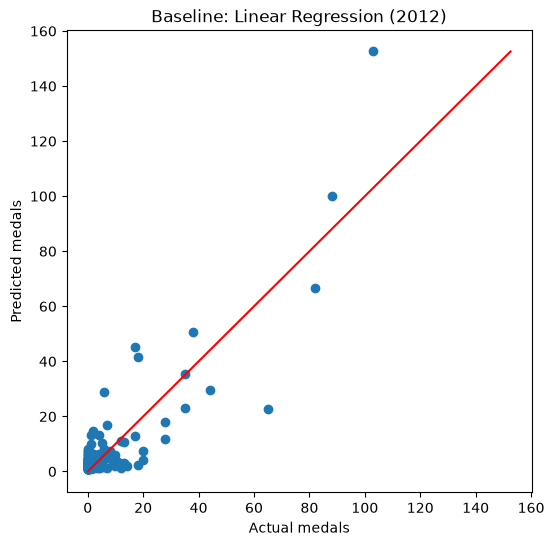

      NOC  Medals  Predicted
1326  USA     103      152.6
1168  CHN      88      100.2
1288  RUS      82       66.6
1198  GBR      65       22.6
1202  GER      44       29.7


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

X_train, y_train = train[features], train["Medals"]
X_valid, y_valid = valid[features], valid["Medals"]

# Train the baseline
lin = LinearRegression()
lin.fit(X_train, y_train)

# Predict, and don't allow negative medal counts
pred = np.clip(lin.predict(X_valid), 0, None)

rmse = np.sqrt(mean_squared_error(y_valid, pred))
mae = mean_absolute_error(y_valid, pred)
print("Baseline Linear Regression on 2012 validation set")
print("RMSE:", round(rmse, 2), "  MAE:", round(mae, 2))

# Chart: actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_valid, pred)
m = max(y_valid.max(), pred.max())
plt.plot([0, m], [0, m], "r")
plt.xlabel("Actual medals")
plt.ylabel("Predicted medals")
plt.title("Baseline: Linear Regression (2012)")
plt.show()

# Table of the top 5 countries
check = valid[["NOC", "Medals"]].copy()
check["Predicted"] = pred.round(1)
print(check.sort_values("Medals", ascending=False).head(5))

Baseline Linear Regression RMSE: 7.36

GaussianNB: accuracy 0.755  RMSE 3.64  MAE 1.78
RandomForest: accuracy 0.870  RMSE 2.75  MAE 1.35

Best two-step model: RandomForest


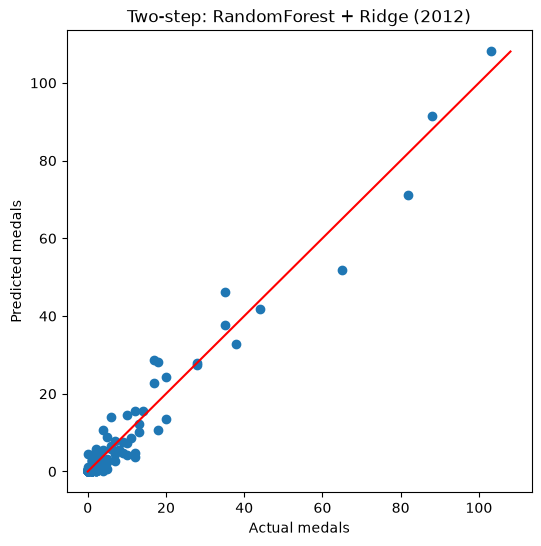

      NOC  Medals  Predicted
1326  USA     103      108.1
1168  CHN      88       91.6
1288  RUS      82       71.1
1198  GBR      65       51.9
1202  GER      44       41.8


In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

y_train_bin = (y_train > 0).astype(int)
y_valid_bin = (y_valid > 0).astype(int)

# Step 2 model: trained only on countries that actually won medals
won = train["Medals"] > 0
reg = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
reg.fit(X_train[won], y_train[won])

classifiers = {
    "GaussianNB": GaussianNB(),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=0),
}

results = {}
print("Baseline Linear Regression RMSE:", round(rmse, 2))
print()
for name, clf in classifiers.items():
    clf.fit(X_train, y_train_bin)
    will_win = clf.predict(X_valid) == 1

    pred2 = np.zeros(len(X_valid))
    if will_win.any():
        pred2[will_win] = np.clip(reg.predict(X_valid[will_win]), 0, None)

    acc = accuracy_score(y_valid_bin, will_win)
    r = np.sqrt(mean_squared_error(y_valid, pred2))
    m = mean_absolute_error(y_valid, pred2)
    results[name] = (r, pred2)
    print(f"{name}: accuracy {acc:.3f}  RMSE {r:.2f}  MAE {m:.2f}")

# Chart for the best two-step model
best = min(results, key=lambda k: results[k][0])
pred_best = results[best][1]
print("\nBest two-step model:", best)

plt.figure(figsize=(6, 6))
plt.scatter(y_valid, pred_best)
mx = max(y_valid.max(), pred_best.max())
plt.plot([0, mx], [0, mx], "r")
plt.xlabel("Actual medals")
plt.ylabel("Predicted medals")
plt.title(f"Two-step: {best} + Ridge (2012)")
plt.show()

check = valid[["NOC", "Medals"]].copy()
check["Predicted"] = pred_best.round(1)
print(check.sort_values("Medals", ascending=False).head(5))

Baseline Linear Regression: RMSE 7.55  MAE 4.07
Two-step RandomForest + Ridge: RMSE 3.73  MAE 1.59


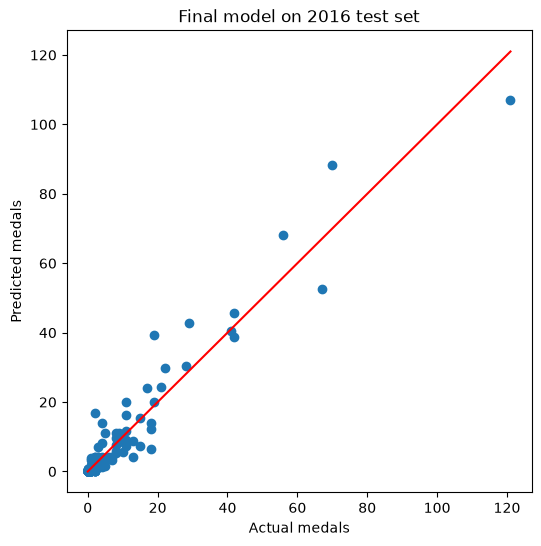

      NOC  Medals  Predicted
1533  USA     121      107.1
1373  CHN      70       88.4
1403  GBR      67       52.5
1494  RUS      56       68.0
1407  GER      42       45.7
1399  FRA      42       38.8
1432  JPN      41       40.4
1345  AUS      29       42.8


In [11]:
import os
os.makedirs("../results", exist_ok=True)

# Retrain on train + validation (1992-2012)
trainval = pd.concat([train, valid])
Xtv, ytv = trainval[features], trainval["Medals"]
X_test, y_test = test[features], test["Medals"]

# Baseline
lin_f = LinearRegression().fit(Xtv, ytv)
pred_base = np.clip(lin_f.predict(X_test), 0, None)

# Two-step: RandomForest classifier + Ridge regressor
clf_f = RandomForestClassifier(n_estimators=200, random_state=0)
clf_f.fit(Xtv, (ytv > 0).astype(int))
won_f = ytv > 0
reg_f = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtv[won_f], ytv[won_f])

will_win = clf_f.predict(X_test) == 1
pred_final = np.zeros(len(X_test))
pred_final[will_win] = np.clip(reg_f.predict(X_test[will_win]), 0, None)

for name, p in [("Baseline Linear Regression", pred_base),
                ("Two-step RandomForest + Ridge", pred_final)]:
    print(f"{name}: RMSE {np.sqrt(mean_squared_error(y_test, p)):.2f}  "
          f"MAE {mean_absolute_error(y_test, p):.2f}")

# Final chart, saved as a file
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_final)
mx = max(y_test.max(), pred_final.max())
plt.plot([0, mx], [0, mx], "r")
plt.xlabel("Actual medals")
plt.ylabel("Predicted medals")
plt.title("Final model on 2016 test set")
plt.savefig("../results/final_2016.png", dpi=150, bbox_inches="tight")
plt.show()

# Top-8 table, saved as a file
out = test[["NOC", "Medals"]].copy()
out["Predicted"] = pred_final.round(1)
out = out.sort_values("Medals", ascending=False)
out.to_csv("../results/predictions_2016.csv", index=False)
print(out.head(8))